# Dataset analysis

Hero pick counts and win rates across complete parsed matches.

In [3]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module

importlib.reload(dataset_module)

DatasetMaker = dataset_module.DatasetMaker
HERO_ALIASES = dataset_module.HERO_ALIASES
HEROES_PATH = dataset_module.HEROES_PATH
normalize_hero_name = dataset_module.normalize_hero_name

In [4]:
HERO_PICK_STATS_QUERY = """
    WITH complete_matches AS (
        SELECT
            m.match_id
        FROM dotabuff_matches m
        JOIN dotabuff_match_players p ON p.match_id = m.match_id
        WHERE
            m.winner_side IN ('radiant', 'dire')
            AND p.side IN ('radiant', 'dire')
            AND p.hero_slug IS NOT NULL
        GROUP BY m.match_id
        HAVING
            COUNT(*) = 10
            AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5
            AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5
    )
    SELECT
        p.hero_slug,
        COUNT(*)::int AS appearances,
        COUNT(*) FILTER (WHERE p.side = m.winner_side)::int AS wins,
        COUNT(*) FILTER (WHERE p.side = 'radiant')::int AS radiant_picks,
        COUNT(*) FILTER (WHERE p.side = 'dire')::int AS dire_picks,
        COUNT(*) FILTER (WHERE p.side = 'radiant' AND m.winner_side = 'radiant')::int AS radiant_wins,
        COUNT(*) FILTER (WHERE p.side = 'dire' AND m.winner_side = 'dire')::int AS dire_wins
    FROM complete_matches cm
    JOIN dotabuff_matches m ON m.match_id = cm.match_id
    JOIN dotabuff_match_players p ON p.match_id = cm.match_id
    WHERE
        p.side IN ('radiant', 'dire')
        AND p.hero_slug IS NOT NULL
    GROUP BY p.hero_slug
    ORDER BY appearances DESC
"""

In [5]:
def load_hero_name_by_key(path=HEROES_PATH):
    heroes = json.loads(Path(path).read_text(encoding="utf-8"))
    names = {}

    for hero in heroes.values():
        localized_name = hero.get("localized_name")
        internal_name = hero.get("name")
        if not localized_name:
            continue

        names[normalize_hero_name(localized_name)] = localized_name
        if internal_name:
            short_name = internal_name.removeprefix("npc_dota_hero_")
            names[normalize_hero_name(short_name)] = localized_name

    return names


hero_name_by_key = load_hero_name_by_key()


def canonical_hero_key(value):
    key = normalize_hero_name(value)
    return HERO_ALIASES.get(key, key)


def hero_display_name(canonical_key):
    return hero_name_by_key.get(canonical_key, canonical_key)

In [6]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(HERO_PICK_STATS_QUERY)
        rows = cur.fetchall()

raw_stats = pd.DataFrame(rows)
raw_stats.head(), raw_stats.shape

(  hero_slug  appearances  wins  radiant_picks  dire_picks  radiant_wins  \
 0    jakiro          475   214            222         253           102   
 1      tiny          411   196            193         218            92   
 2  hoodwink          388   207            196         192           107   
 3   phoenix          357   183            168         189            87   
 4      tusk          356   167            183         173            92   
 
    dire_wins  
 0        112  
 1        104  
 2        100  
 3         96  
 4         75  ,
 (127, 7))

In [7]:
stats = raw_stats.copy()
stats["hero_key"] = stats["hero_slug"].map(canonical_hero_key)

hero_stats = (
    stats.groupby("hero_key", as_index=False)[
        ["appearances", "wins", "radiant_picks", "dire_picks", "radiant_wins", "dire_wins"]
    ]
    .sum()
    .assign(
        hero=lambda df: df["hero_key"].map(hero_display_name),
        win_rate=lambda df: df["wins"] / df["appearances"],
        radiant_win_rate=lambda df: df["radiant_wins"] / df["radiant_picks"].where(df["radiant_picks"] > 0),
        dire_win_rate=lambda df: df["dire_wins"] / df["dire_picks"].where(df["dire_picks"] > 0),
    )
    .sort_values(["appearances", "win_rate"], ascending=[False, False])
)

hero_stats = hero_stats[
    [
        "hero",
        "hero_key",
        "appearances",
        "wins",
        "win_rate",
        "radiant_picks",
        "radiant_wins",
        "radiant_win_rate",
        "dire_picks",
        "dire_wins",
        "dire_win_rate",
    ]
]

hero_stats.tail(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
24,Death Prophet,deathprophet,17,9,0.529412,12,8,0.666667,5,1,0.200000
57,Magnus,magnus,15,8,0.533333,7,4,0.571429,8,4,0.500000
72,Omniknight,omniknight,15,6,0.400000,5,2,0.400000,10,4,0.400000
28,Drow Ranger,drowranger,15,5,0.333333,9,4,0.444444,6,1,0.166667
77,Phantom Lancer,phantomlancer,13,5,0.384615,8,5,0.625000,5,0,0.000000
124,Witch Doctor,witchdoctor,12,7,0.583333,6,4,0.666667,6,3,0.500000
52,Lina,lina,12,5,0.416667,4,2,0.500000,8,3,0.375000
126,Zeus,zeus,11,6,0.545455,5,3,0.600000,6,3,0.500000
48,Legion Commander,legioncommander,9,6,0.666667,6,4,0.666667,3,2,0.666667
31,Elder Titan,eldertitan,9,3,0.333333,5,2,0.400000,4,1,0.250000


In [8]:
summary = {
    "unique_raw_hero_slugs": raw_stats["hero_slug"].nunique(),
    "unique_canonical_heroes": hero_stats["hero_key"].nunique(),
    "total_hero_appearances": int(hero_stats["appearances"].sum()),
    "complete_matches": int(hero_stats["appearances"].sum() / 10),
}

summary

{'unique_raw_hero_slugs': 127,
 'unique_canonical_heroes': 127,
 'total_hero_appearances': 14270,
 'complete_matches': 1427}

In [9]:
hero_stats.sort_values("appearances", ascending=False).head(30)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
42,Jakiro,jakiro,475,214,0.450526,222,102,0.459459,253,112,0.442688
108,Tiny,tiny,411,196,0.476886,193,92,0.476684,218,104,0.477064
38,Hoodwink,hoodwink,388,207,0.533505,196,107,0.545918,192,100,0.520833
78,Phoenix,phoenix,357,183,0.512605,168,87,0.517857,189,96,0.507937
111,Tusk,tusk,356,167,0.469101,183,92,0.502732,173,75,0.433526
120,Warlock,warlock,322,160,0.496894,154,67,0.435065,168,93,0.553571
32,Ember Spirit,emberspirit,318,168,0.528302,163,79,0.484663,155,89,0.574194
80,Puck,puck,299,146,0.488294,155,73,0.470968,144,73,0.506944
89,Shadow Demon,shadowdemon,296,165,0.557432,147,82,0.557823,149,83,0.557047
8,Beastmaster,beastmaster,290,138,0.475862,157,77,0.490446,133,61,0.458647


In [10]:
MIN_APPEARANCES = 20

popular_heroes = hero_stats[hero_stats["appearances"] >= MIN_APPEARANCES]
popular_heroes.sort_values("win_rate", ascending=False).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
54,Lone Druid,lonedruid,44,32,0.727273,12,10,0.833333,32,22,0.687500
13,Broodmother,broodmother,24,16,0.666667,8,7,0.875000,16,9,0.562500
109,Treant Protector,treantprotector,170,109,0.641176,71,51,0.718310,99,58,0.585859
123,Winter Wyvern,winterwyvern,34,21,0.617647,14,12,0.857143,20,9,0.450000
61,Meepo,meepo,23,14,0.608696,12,6,0.500000,11,8,0.727273
82,Pugna,pugna,73,44,0.602740,42,25,0.595238,31,19,0.612903
19,Crystal Maiden,crystalmaiden,30,18,0.600000,15,7,0.466667,15,11,0.733333
39,Huskar,huskar,84,50,0.595238,40,22,0.550000,44,28,0.636364
47,Largo,largo,217,129,0.594470,90,51,0.566667,127,78,0.614173
35,Faceless Void,facelessvoid,106,63,0.594340,54,33,0.611111,52,30,0.576923


In [11]:
popular_heroes.sort_values("win_rate", ascending=True).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
113,Undying,undying,29,9,0.310345,20,6,0.300000,9,3,0.333333
22,Dawnbreaker,dawnbreaker,50,18,0.360000,31,11,0.354839,19,7,0.368421
56,Lycan,lycan,27,10,0.370370,16,8,0.500000,11,2,0.181818
50,Lich,lich,23,9,0.391304,11,5,0.454545,12,4,0.333333
0,Abaddon,abaddon,78,31,0.397436,46,15,0.326087,32,16,0.500000
110,Troll Warlord,trollwarlord,30,12,0.400000,14,6,0.428571,16,6,0.375000
96,Snapfire,snapfire,45,18,0.400000,31,13,0.419355,14,5,0.357143
55,Luna,luna,109,44,0.403670,53,26,0.490566,56,18,0.321429
68,Necrophos,necrophos,27,11,0.407407,10,4,0.400000,17,7,0.411765
102,Techies,techies,54,22,0.407407,25,13,0.520000,29,9,0.310345


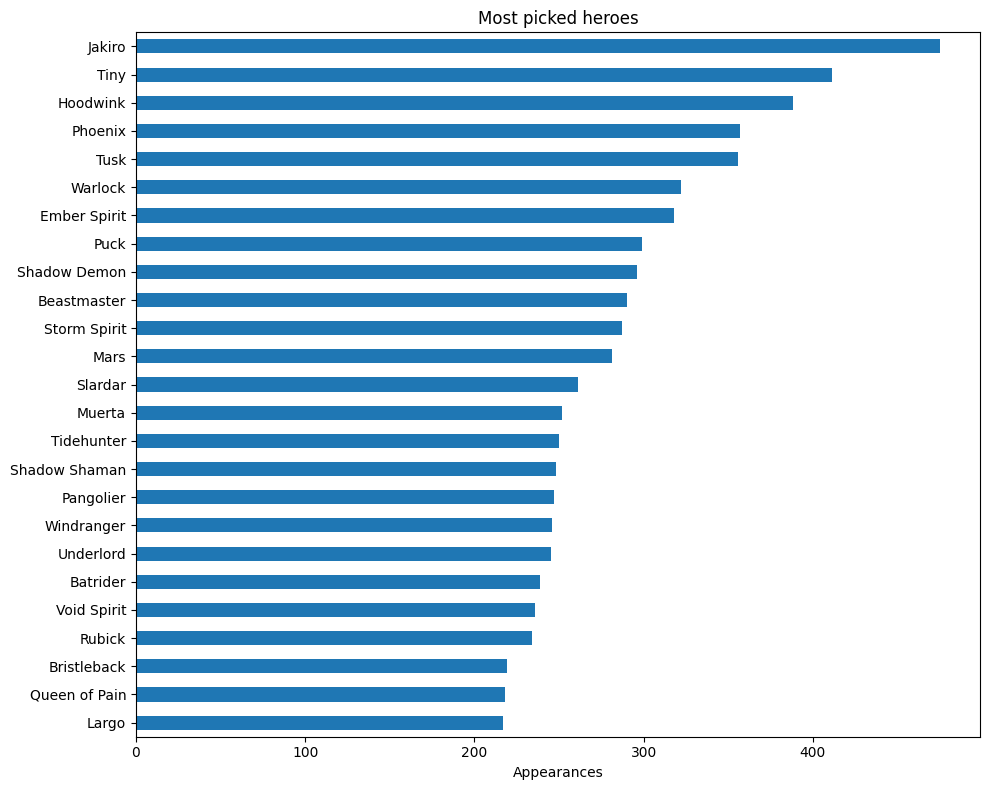

In [12]:
top_picked = hero_stats.sort_values("appearances", ascending=False).head(25).sort_values("appearances")

ax = top_picked.plot.barh(x="hero", y="appearances", figsize=(10, 8), legend=False)
ax.set_title("Most picked heroes")
ax.set_xlabel("Appearances")
ax.set_ylabel("")
plt.tight_layout()

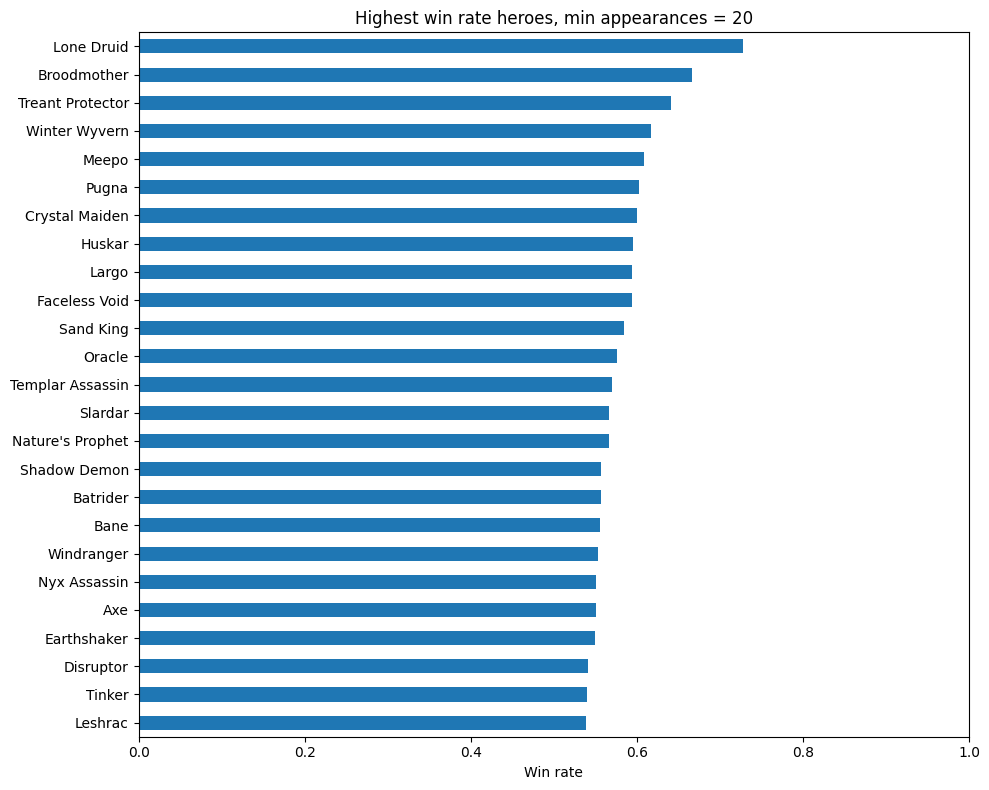

In [13]:
top_win_rate = popular_heroes.sort_values("win_rate", ascending=False).head(25).sort_values("win_rate")

ax = top_win_rate.plot.barh(x="hero", y="win_rate", figsize=(10, 8), legend=False)
ax.set_title(f"Highest win rate heroes, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()

## Histograms

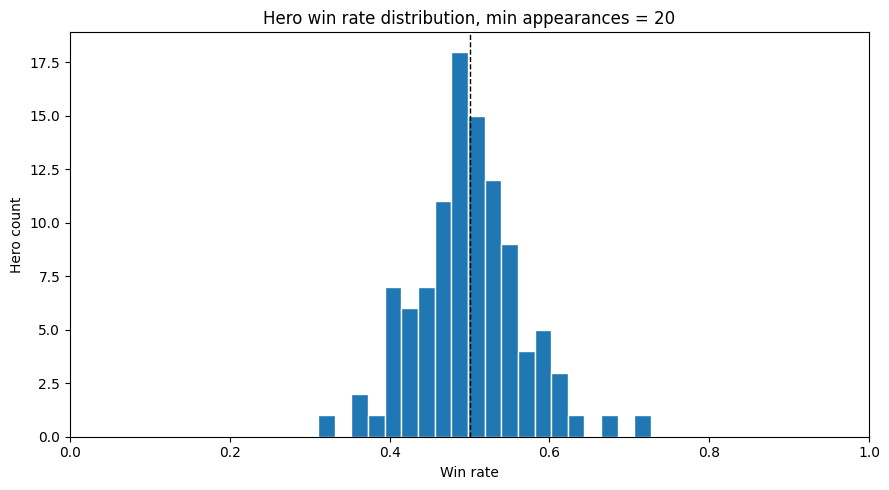

In [14]:
ax = popular_heroes["win_rate"].plot.hist(bins=20, figsize=(9, 5), edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Hero win rate distribution, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("Hero count")
ax.set_xlim(0, 1)
plt.tight_layout()

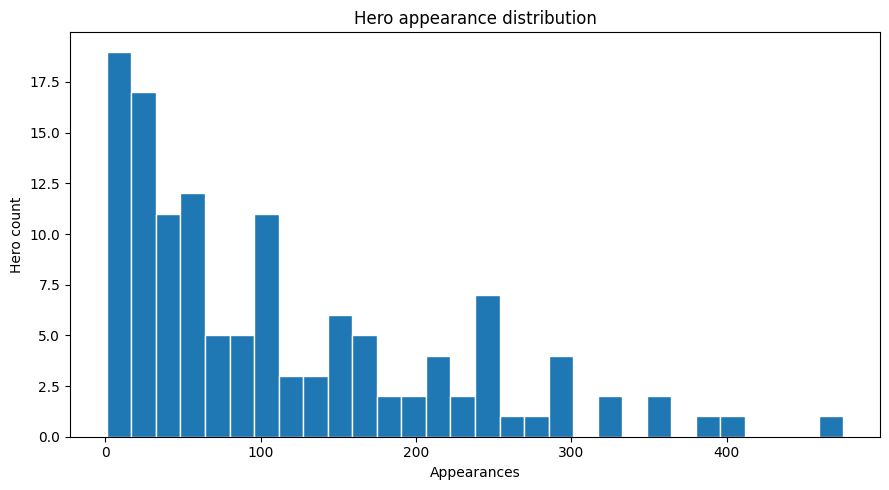

In [15]:
ax = hero_stats["appearances"].plot.hist(bins=30, figsize=(9, 5), edgecolor="white")
ax.set_title("Hero appearance distribution")
ax.set_xlabel("Appearances")
ax.set_ylabel("Hero count")
plt.tight_layout()

In [16]:
hero_stats.to_csv(PROJECT_ROOT / "notebooks" / "hero_pick_win_rates.csv", index=False)
PROJECT_ROOT / "notebooks" / "hero_pick_win_rates.csv"

PosixPath('/Users/meowmeow/Documents/MyDocs/Code/repos/dota-predictor/notebooks/hero_pick_win_rates.csv')